<a href="https://colab.research.google.com/github/DinethPerera-eng/Statistical-Learning-e22285/blob/main/Bayesian_Inference_Assignment_E22285.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Q. Bayesian Estimation of a User Ability Parameter from Item Responses

An online learning platform presents a user with a sequence of $n$ multiple-choice questions **one at a time**. Each question is either answered correctly or incorrectly, allowing the platform to update its estimate of the user's ability dynamically after every response.

Let $Y_i$ denote the user's response to the $i$-th item encountered:

$$Y_i=
\begin{cases}
1, & \text{if the user answers item } i \text{ correctly},\\
0, & \text{if the user answers item } i \text{ incorrectly}.
\end{cases}$$

The platform assumes that the probability of a correct response is governed by a two-parameter logistic (2PL) item response model. Specifically, conditional on the user's latent ability parameter $\Theta=\theta$, the response probability for item $i$ is:

$$P(Y_i=1\mid \Theta=\theta)=p_i(\theta)=\frac{1}{1+e^{-a_i(\theta-b_i)}},$$

where $a_i>0$ is the known discrimination parameter, and $b_i$ is the known difficulty parameter of item $i$.

Let $\mathbf{y}^{(k)} = (y_1, y_2, \dots, y_k)$ represent the **running vector of observed responses** up to the current step $k$ (where $1 \le k \le n$).

Before observing any responses, the platform initializes the user's latent ability estimate with a standard normal prior distribution:

$$f_{\Theta}^{(0)}(\theta) = \frac{1}{\sqrt{2\pi}} \exp\left(-\frac{\theta^2}{2}\right) \quad \text{implying} \quad \Theta \sim \mathscr{N}(0,1).$$

As the user progresses, the posterior distribution at step $k-1$ serves as the prior distribution for step $k$.

---

### Tasks

1. **Visualizing the Mechanics:** Plot $P(Y_i=1\mid \Theta=\theta)$ vs $\theta$ using Plotly for two distinct values of $a_i$, where one of those $a_i$ values is paired with three different difficulty values of $b_i$. Interpret how moving $b_i$ shifts the curve horizontally.
2. **Sequential Likelihood Contribution:** Write down the likelihood contribution $L(y_k \mid \theta)$ of a *single* new response $y_k$ at step $k$, given the latent ability $\theta$. Then, write down the joint likelihood function for the running history vector $\mathbf{y}^{(k)}$.
3. **Mathematical Formulation of the Running Update:** Write down the recursive relationship for the posterior density at step $k$, denoted $f_{\Theta \mid \mathbf{Y}^{(k)}}(\theta \mid \mathbf{y}^{(k)})$, up to a proportionality constant, using the prior state $f_{\Theta \mid \mathbf{Y}^{(k-1)}}(\theta \mid \mathbf{y}^{(k-1)})$ and the new observation $y_k$.
4. **Dynamic Shifting:** Explain how a correct answer ($y_k = 1$) to a highly difficult item (large $b_k$) mathematically shifts the peak of the running posterior density distribution relative to the previous step.
5. **Tracking Certainty and Sharpness:** Explain how the discrimination parameter $a_k$ of the current item alters the variance (or "sharpness") of the distribution during a running update. What happens when $a_k$ is very large versus very small?
6. **Numerical Implementation of a Running Grid:** Describe a algorithmic approach to numerically approximate and maintain this running posterior density function on a fixed grid of $\theta$-values. Explicitly state how you would perform the sequential normalization step computationally after an item is answered.


7. **Evaluating Convergence over the Timeline:** Suppose the user's true, hidden latent ability is $\theta_{\text{true}} = 0.75$. Write a Python script that extends your previous grid simulation to track the performance of the running estimators over a sequence of $n = 20$ items.
* **Simulate Responses:** Dynamically generate the user's responses $y_k \in \{0, 1\}$ at each step by comparing a random draw from a Uniform distribution $U(0,1)$ against the true response probability $p_k(\theta_{\text{true}})$. Give each item a random difficulty $b_k \sim \mathscr{N}(0, 1)$ and a random discrimination $a_k \sim \text{Uniform}(0.5, 2.0)$.
* **Track Estimators:** At each step $k$, calculate and store the running Posterior Mean ($\widehat{\theta}_{\mathrm{Bayes}}^{(k)}$) and the running Maximum A Posteriori ($\widehat{\theta}_{\mathrm{MAP}}^{(k)}$) estimate.
* **Visualize:** Use Plotly to create a single line chart showing the progression of both estimators from step $0$ to $20$. Add a static horizontal reference line at $y = 0.75$ representing $\theta_{\text{true}}$.
* **Analysis:** Briefly explain how the distance between your estimators and $\theta_{\text{true}}$ changes as $k$ increases, and interpret what this implies about the platform's confidence in its measurement.


In [5]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from scipy.stats import beta as beta_dist
from scipy.stats import norm
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

%matplotlib inline

In [14]:
pip install gdown

## Solution 1.1 — Visualizing the 2PL Response Curves

The 2PL item response function is

$$
p_i(\theta)=P(Y_i=1\mid\Theta=\theta)
=\frac{1}{1+\exp[-a_i(\theta-b_i)]}.
$$

The difficulty parameter $b_i$ is the ability value at which the probability of a correct answer is $0.5$. Therefore, increasing $b_i$ shifts the curve to the right. The discrimination parameter $a_i$ controls the steepness of the curve.

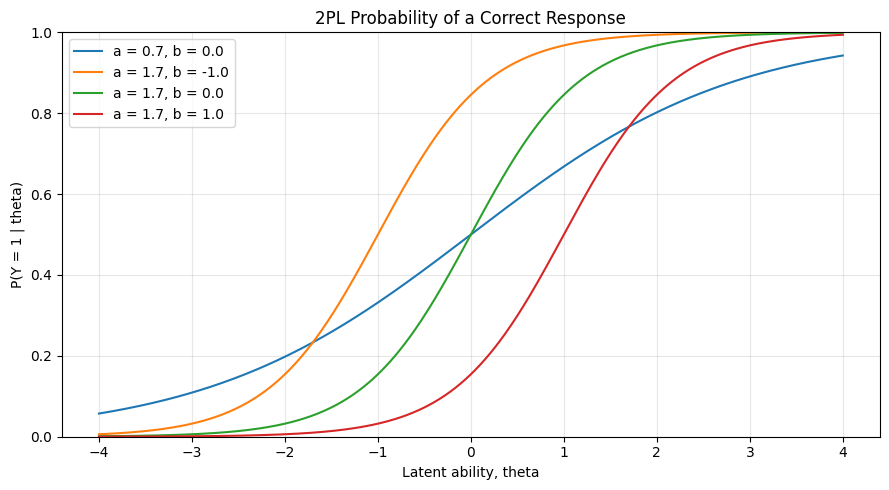

In [6]:
# Create the ability grid.
theta = np.linspace(-4, 4, 600)

# Define different discrimination and difficulty settings.
curve_settings = [
    {"a": 0.7, "b": 0.0, "label": "a = 0.7, b = 0.0"},
    {"a": 1.7, "b": -1.0, "label": "a = 1.7, b = -1.0"},
    {"a": 1.7, "b": 0.0, "label": "a = 1.7, b = 0.0"},
    {"a": 1.7, "b": 1.0, "label": "a = 1.7, b = 1.0"},
]

plt.figure(figsize=(9, 5))

for setting in curve_settings:
    probability = 1 / (
        1 + np.exp(-setting["a"] * (theta - setting["b"]))
    )
    plt.plot(theta, probability, label=setting["label"])

plt.title("2PL Probability of a Correct Response")
plt.xlabel("Latent ability, theta")
plt.ylabel("P(Y = 1 | theta)")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation

For fixed $a_i=1.7$, changing $b_i$ from $-1$ to $0$ to $1$ moves the midpoint of the curve from left to right. A more difficult item requires a larger ability value to achieve the same probability of success. The curve with $a_i=0.7$ is flatter, so it separates users of different abilities less strongly than the curves with $a_i=1.7$.

## Solution 1.2 — Sequential Likelihood Contribution

For one observed response $y_k\in\{0,1\}$,

$$
L(y_k\mid\theta)
=
[p_k(\theta)]^{y_k}
[1-p_k(\theta)]^{1-y_k},
$$

where

$$
p_k(\theta)=\frac{1}{1+\exp[-a_k(\theta-b_k)]}.
$$

Thus, the likelihood of the running response history
$\mathbf y^{(k)}=(y_1,\ldots,y_k)$, assuming conditional independence, is

$$
L(\mathbf y^{(k)}\mid\theta)
=
\prod_{i=1}^{k}
[p_i(\theta)]^{y_i}
[1-p_i(\theta)]^{1-y_i}.
$$

## Solution 1.3 — Recursive Running Posterior Update

Let $f_{k-1}(\theta)$ denote the posterior after the first $k-1$ responses. When response $y_k$ arrives,

$$
f_k(\theta)
\propto
L(y_k\mid\theta)f_{k-1}(\theta).
$$

The normalized expression is

$$
f_k(\theta)
=
\frac{
[p_k(\theta)]^{y_k}[1-p_k(\theta)]^{1-y_k}
f_{k-1}(\theta)
}{
\int_{-\infty}^{\infty}
[p_k(u)]^{y_k}[1-p_k(u)]^{1-y_k}
f_{k-1}(u)\,du
}.
$$

At step $0$,

$$
f_0(\theta)=\frac{1}{\sqrt{2\pi}}e^{-\theta^2/2}.
$$

The 2PL likelihood is not conjugate to the normal prior, so the posterior does not generally belong to a standard named family.

## Solution 1.4 — Effect of a Correct Answer to a Difficult Item

For $y_k=1$, the update multiplies the previous posterior by $p_k(\theta)$. When $b_k$ is large, $p_k(\theta)$ is small for low values of $\theta$ and becomes large only at higher abilities. Therefore,

$$
f_k(\theta)\propto p_k(\theta)f_{k-1}(\theta)
$$

strongly downweights low-ability values. The posterior mass and its peak usually move to the right. A correct response to a difficult item is therefore strong evidence of higher ability.

## Solution 1.5 — Effect of the Discrimination Parameter

The information supplied by a 2PL item at ability $\theta$ is

$$
I_k(\theta)=a_k^2p_k(\theta)[1-p_k(\theta)].
$$

A large $a_k$ creates a steep response curve. The likelihood changes rapidly near $b_k$, so one response can produce a sharper posterior and a larger reduction in uncertainty. A small $a_k$ creates a flatter likelihood; the response changes the posterior only slightly, so the posterior variance decreases more slowly.

## Solution 1.6 — Fixed-Grid Numerical Algorithm

1. Choose a sufficiently wide grid, such as $\theta_j\in[-4,4]$.
2. Evaluate the standard normal prior on the grid.
3. Normalize the prior using the trapezoidal rule.
4. For each new response $y_k$:
   - calculate $p_k(\theta_j)$;
   - calculate $L_k(\theta_j)=p_k(\theta_j)^{y_k}[1-p_k(\theta_j)]^{1-y_k}$;
   - multiply the previous grid density by $L_k$;
   - calculate $Z_k=\operatorname{trapz}(\widetilde f_k,\theta)$;
   - normalize using $f_k(\theta_j)=\widetilde f_k(\theta_j)/Z_k$.
5. Compute the posterior mean by numerical integration and the MAP using the grid point with the largest density.

## Solution 1.7 — Sequential Simulation and Convergence

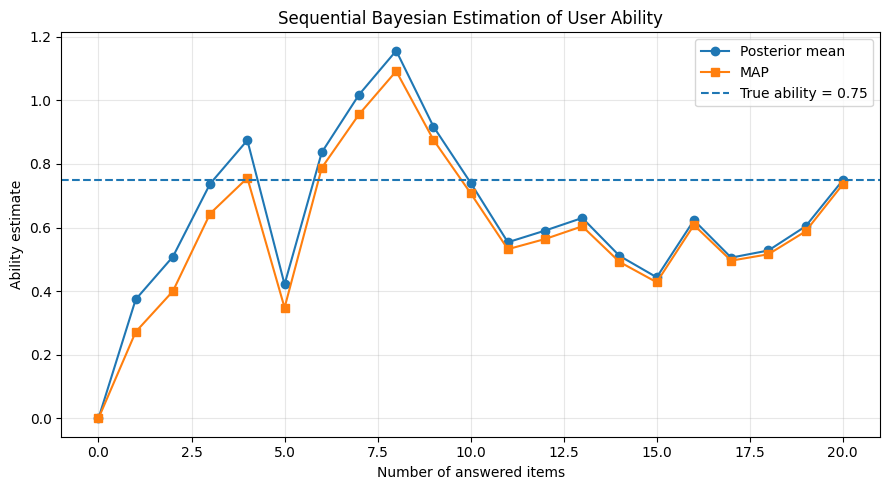

Correct responses: 13 out of 20
Final posterior mean: 0.7489
Final MAP estimate: 0.7360
Posterior SD: 0.9995 at step 0 -> 0.3524 at step 20


,step,difficulty_b,discrimination_a,true_success_probability,response,posterior_mean,MAP,posterior_sd
0,1,-0.676549,1.872703,0.935324,1,0.374171,0.272,0.845824
1,2,-1.093905,1.058502,0.875640,1,0.508461,0.400,0.816475
2,3,0.046412,0.986212,0.666831,1,0.737922,0.644,0.789453
3,4,-0.480352,1.775358,0.898832,1,0.874640,0.756,0.743281
4,5,0.266980,1.565111,0.680480,0,0.421421,0.348,0.611808
5,6,1.011158,1.889071,0.379106,1,0.836570,0.788,0.579101
6,7,0.450988,1.901219,0.638414,1,1.017822,0.956,0.541179
7,8,0.738024,1.250897,0.503745,1,1.156253,1.092,0.530864
8,9,0.052534,1.214156,0.699902,0,0.917773,0.876,0.486983
9,10,-0.622053,0.979700,0.793180,0,0.740797,0.708,0.463582


In [7]:
# Reproducible random-number generator.
rng = np.random.default_rng(78)

# Simulation settings.
theta_true = 0.75
n_items = 20
theta_grid = np.linspace(-4, 4, 2001)

# Standard normal prior evaluated on the grid.
posterior = norm.pdf(theta_grid, loc=0, scale=1)
posterior = posterior / np.trapezoid(posterior, theta_grid)

# Store estimates from step 0 onward.
posterior_means = [
    np.trapezoid(theta_grid * posterior, theta_grid)
]
posterior_maps = [
    theta_grid[np.argmax(posterior)]
]
posterior_sds = [
    np.sqrt(
        np.trapezoid(
            (theta_grid - posterior_means[0]) ** 2 * posterior,
            theta_grid,
        )
    )
]

records = []

# Process the item responses one at a time.
for step in range(1, n_items + 1):
    difficulty_b = rng.normal(0, 1)
    discrimination_a = rng.uniform(0.5, 2.0)

    true_probability = 1 / (
        1
        + np.exp(
            -discrimination_a * (theta_true - difficulty_b)
        )
    )

    response = int(rng.random() < true_probability)

    probability_grid = 1 / (
        1
        + np.exp(
            -discrimination_a * (theta_grid - difficulty_b)
        )
    )

    if response == 1:
        likelihood = probability_grid
    else:
        likelihood = 1 - probability_grid

    # Recursive Bayesian update.
    posterior = posterior * likelihood
    posterior = posterior / np.trapezoid(
        posterior,
        theta_grid,
    )

    posterior_mean = np.trapezoid(
        theta_grid * posterior,
        theta_grid,
    )
    posterior_map = theta_grid[np.argmax(posterior)]
    posterior_sd = np.sqrt(
        np.trapezoid(
            (theta_grid - posterior_mean) ** 2 * posterior,
            theta_grid,
        )
    )

    posterior_means.append(posterior_mean)
    posterior_maps.append(posterior_map)
    posterior_sds.append(posterior_sd)

    records.append(
        {
            "step": step,
            "difficulty_b": difficulty_b,
            "discrimination_a": discrimination_a,
            "true_success_probability": true_probability,
            "response": response,
            "posterior_mean": posterior_mean,
            "MAP": posterior_map,
            "posterior_sd": posterior_sd,
        }
    )

irt_results = pd.DataFrame(records)

steps = np.arange(0, n_items + 1)

plt.figure(figsize=(9, 5))
plt.plot(
    steps,
    posterior_means,
    marker="o",
    label="Posterior mean",
)
plt.plot(
    steps,
    posterior_maps,
    marker="s",
    label="MAP",
)
plt.axhline(
    theta_true,
    linestyle="--",
    label="True ability = 0.75",
)
plt.title("Sequential Bayesian Estimation of User Ability")
plt.xlabel("Number of answered items")
plt.ylabel("Ability estimate")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(
    f"Correct responses: "
    f"{irt_results['response'].sum()} out of {n_items}"
)
print(
    f"Final posterior mean: "
    f"{posterior_means[-1]:.4f}"
)
print(
    f"Final MAP estimate: "
    f"{posterior_maps[-1]:.4f}"
)
print(
    f"Posterior SD: {posterior_sds[0]:.4f} "
    f"at step 0 -> {posterior_sds[-1]:.4f} "
    f"at step 20"
)

display(irt_results)

### Convergence Analysis

Using the fixed seed, the final posterior mean is approximately $0.749$, the final MAP is approximately $0.736$, and the posterior standard deviation decreases from about $1.00$ to $0.35$. Individual responses cause temporary upward or downward movements, but the estimates become more stable as evidence accumulates. The decreasing posterior spread indicates that the platform becomes more confident about the user's ability.

# Q. Bayesian Tracking of Click-Through Rates (CTR) via Conjugate Beta-Binomial Updates

An e-commerce platform wants to optimize its recommendation engine by dynamically estimating the click-through rate (CTR) of a newly launched advertisement. Since user traffic arrives continuously, the platform updates its belief about the advertisement's performance **one impression at a time** rather than waiting for large batch updates.

Let $\Theta = \theta$ represent the true, hidden conversion rate (probability of a click) of the advertisement, where $\theta \in [0, 1]$.

Let $Y_k$ denote a single user's interaction with the advertisement at time step $k$:

$$Y_k =
\begin{cases}
1, & \text{if the user clicks the advertisement}, \\
0, & \text{if the user does not click the advertisement}.
\end{cases}$$

The platform assumes that conditional on the true conversion rate $\Theta = \theta$, each user interaction is an independent Bernoulli trial:

$$P(Y_k = 1 \mid \Theta = \theta) = \theta$$

Let $\mathbf{y}^{(k)} = (y_1, y_2, \dots, y_k)$ represent the **running vector of observed user interactions** up to the current impression step $k$ (where $1 \le k \le n$).

Before observing any data, the platform assigns a flexible **Beta distribution** as the initial prior over the unknown parameter $\Theta$:

$$f_{\Theta}^{(0)}(\theta) = \frac{1}{\mathrm{B}(\alpha_0, \beta_0)} \theta^{\alpha_0 - 1} (1 - \theta)^{\beta_0 - 1} \quad \text{implying} \quad \Theta \sim \text{Beta}(\alpha_0, \beta_0)$$

where $\mathrm{B}(\cdot, \cdot)$ is the Beta function acting as the normalizing constant. Under a sequential framework, the posterior distribution at step $k-1$ serves directly as the prior distribution for step $k$.

---

**Tasks**

**1. Structural Probability and Properties**
Plot the probability density function (PDF) of a $\text{Beta}(\alpha, \beta)$ distribution using Plotly for three distinct parameter pairs:

* Uninformative state: $(\alpha=1, \beta=1)$
* Right-skewed state: $(\alpha=2, \beta=8)$
* Left-skewed state: $(\alpha=8, \beta=2)$

Interpret how changing the balance between $\alpha$ and $\beta$ shifts the center of mass of the density function over the domain $[0, 1]$.

**2. Sequential Likelihood and Joint History**

Write down the mathematical likelihood contribution $L(y_k \mid \theta)$ of a *single* isolated response $y_k$ at step $k$, given the click probability $\theta$. Following this, express the joint likelihood function for the running history vector $\mathbf{y}^{(k)}$.

**3. Closed-Form Analytical Updates (Conjugacy)**

Using Bayes' Theorem, derive the recursive algebraic relationship for the posterior density at step $k$, denoted as $f_{\Theta \mid \mathbf{Y}^{(k)}}(\theta \mid \mathbf{y}^{(k)})$. Prove analytically that the posterior remains in the Beta family (**Beta-Binomial Conjugacy**) by explicitly writing down the closed-form update parameters $\alpha_k$ and $\beta_k$ as simple arithmetic updates of $\alpha_{k-1}$, $\beta_{k-1}$, and $y_k$. Also compute the **Posterior Mean** of the latent parameter $\Theta$ at time step $k$ (i.e. $\mathbb{E}[\Theta \mid \mathbf{Y}^{(k)}=\mathbf{y}^{(k)}]$).


**4. Dynamic Shifting Mechanics**

Explain how an observed click ($y_k = 1$) vs. a non-click ($y_k = 0$) shifts the peak of the running density distribution mathematically. Contrast this analytical framework against non-conjugate setups (such as the 2PL IRT model) where numerical grid integration is strictly required.

**5. Running Point Estimators**

State the exact closed-form equations used to evaluate the following point estimates at step $k$ directly from the updated shape parameters $\alpha_k$ and $\beta_k$:

* **Running Posterior Mean** ($\widehat{\theta}_{\mathrm{Bayes}}^{(k)}$)
* **Running Maximum A Posteriori** ($\widehat{\theta}_{\mathrm{MAP}}^{(k)}$)

**6. Performance Tracking and Convergence Analysis**

Suppose the advertisement's true, hidden click-through rate is $\theta_{\text{true}} = 0.35$. Write a Python script to track the performance of your closed-form sequential estimators over a timeline of $n = 100$ impressions:

* **Initialize State:** Set the base prior parameters to $\alpha_0 = 1, \beta_0 = 1$ (representing uniform initial uncertainty).
* **Simulate Responses:** Dynamically generate user responses $y_k \in \{0, 1\}$ at each step by comparing a random draw from a Uniform distribution $U(0,1)$ against $\theta_{\text{true}}$.
* **Track Estimators:** Loop through each step, update $\alpha_k$ and $\beta_k$ analytically, and store the computed values for $\widehat{\theta}_{\mathrm{Bayes}}^{(k)}$ and $\widehat{\theta}_{\mathrm{MAP}}^{(k)}$.
* **Visualize:** Use Plotly to create a single line chart showing the progression of both estimators from step $0$ to $100$. Add a static horizontal reference line at $y = 0.35$ representing $\theta_{\text{true}}$.
* **Analysis:** Explain how the distance between your estimators and $\theta_{\text{true}}$ responds as the sampling size $k$ approaches $100$. What does this imply about the accumulation of evidence over time relative to the choice of the initial prior?

## Solution 2.1 — Beta Distribution Shapes

For $\Theta\sim\operatorname{Beta}(\alpha,\beta)$,

$$
f(\theta)=\frac{\theta^{\alpha-1}(1-\theta)^{\beta-1}}{B(\alpha,\beta)},
\qquad 0<\theta<1.
$$

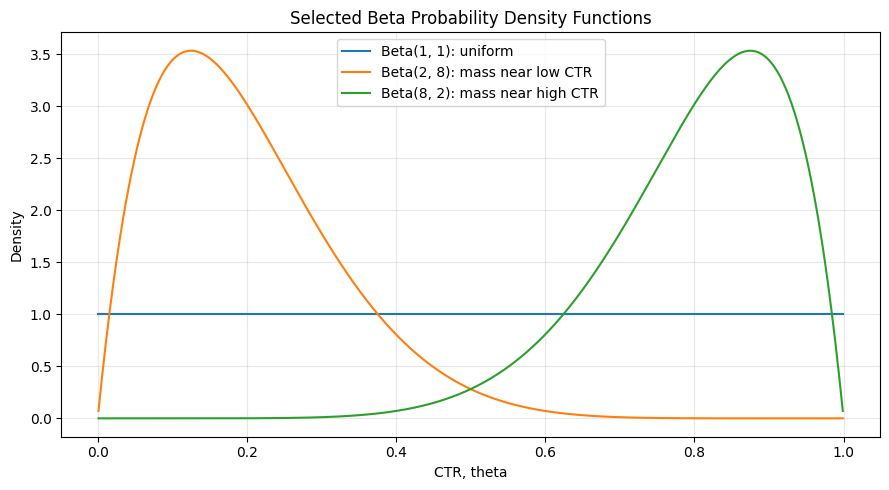

In [8]:
theta = np.linspace(0.001, 0.999, 800)

beta_settings = [
    (1, 1, "Beta(1, 1): uniform"),
    (2, 8, "Beta(2, 8): mass near low CTR"),
    (8, 2, "Beta(8, 2): mass near high CTR"),
]

plt.figure(figsize=(9, 5))

for alpha, beta_parameter, label in beta_settings:
    density = beta_dist.pdf(
        theta,
        alpha,
        beta_parameter,
    )
    plt.plot(theta, density, label=label)

plt.title("Selected Beta Probability Density Functions")
plt.xlabel("CTR, theta")
plt.ylabel("Density")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation

- $\operatorname{Beta}(1,1)$ gives equal density to every value in $[0,1]$.
- $\operatorname{Beta}(2,8)$ places most mass near low CTR values because $\beta>\alpha$.
- $\operatorname{Beta}(8,2)$ places most mass near high CTR values because $\alpha>\beta$.

The center of mass is

$$
E[\Theta]=\frac{\alpha}{\alpha+\beta}.
$$

Therefore, increasing $\alpha$ relative to $\beta$ moves the distribution toward $1$, while increasing $\beta$ relative to $\alpha$ moves it toward $0$.

## Solution 2.2 — Sequential and Joint Likelihoods

For one impression,

$$
L(y_k\mid\theta)
=
\theta^{y_k}(1-\theta)^{1-y_k}.
$$

For the complete running history,

$$
L(\mathbf y^{(k)}\mid\theta)
=
\prod_{i=1}^{k}\theta^{y_i}(1-\theta)^{1-y_i}
=
\theta^{s_k}(1-\theta)^{k-s_k},
$$

where $s_k=\sum_{i=1}^{k}y_i$ is the number of clicks.

## Solution 2.3 — Beta-Bernoulli Conjugate Update

Assume the step-$(k-1)$ posterior is

$$
f_{k-1}(\theta)
\propto
\theta^{\alpha_{k-1}-1}(1-\theta)^{\beta_{k-1}-1}.
$$

After observing $y_k$,

$$
\begin{aligned}
f_k(\theta)
&\propto
\theta^{y_k}(1-\theta)^{1-y_k}
\theta^{\alpha_{k-1}-1}(1-\theta)^{\beta_{k-1}-1}\\
&=
\theta^{\alpha_{k-1}+y_k-1}
(1-\theta)^{\beta_{k-1}+1-y_k-1}.
\end{aligned}
$$

Therefore,

$$
\Theta\mid\mathbf Y^{(k)}
\sim\operatorname{Beta}(\alpha_k,\beta_k),
$$

with the recursive updates

$$
\boxed{\alpha_k=\alpha_{k-1}+y_k},
\qquad
\boxed{\beta_k=\beta_{k-1}+1-y_k}.
$$

Equivalently,

$$
\alpha_k=\alpha_0+\sum_{i=1}^{k}y_i,
\qquad
\beta_k=\beta_0+k-\sum_{i=1}^{k}y_i.
$$

The posterior mean is

$$
\boxed{
E[\Theta\mid\mathbf Y^{(k)}]
=
\frac{\alpha_k}{\alpha_k+\beta_k}
}.
$$

## Solution 2.4 — Dynamic Shifting and Conjugacy

A click increases $\alpha$ by one, moving probability mass toward larger CTR values. A non-click increases $\beta$ by one, moving probability mass toward smaller values. When $\alpha_k>1$ and $\beta_k>1$, the density peak is

$$
\operatorname{mode}(\Theta\mid\mathbf Y^{(k)})
=
\frac{\alpha_k-1}{\alpha_k+\beta_k-2}.
$$

The Beta-Bernoulli model is conjugate, so only two numbers, $\alpha_k$ and $\beta_k$, must be updated. In a non-conjugate model such as 2PL IRT, multiplying the previous posterior by the new likelihood does not produce a known distribution. Numerical integration, grid approximation, or Monte Carlo methods are then required.

## Solution 2.5 — Running Point Estimators

The running posterior mean is

$$
\boxed{
\widehat\theta_{\text{Bayes}}^{(k)}
=
\frac{\alpha_k}{\alpha_k+\beta_k}
}.
$$

For $\alpha_k>1$ and $\beta_k>1$, the MAP is

$$
\boxed{
\widehat\theta_{\text{MAP}}^{(k)}
=
\frac{\alpha_k-1}{\alpha_k+\beta_k-2}
}.
$$

Boundary cases are:

$$
\widehat\theta_{\text{MAP}}=
\begin{cases}
0, & \alpha_k\le1,\ \beta_k>1,\\
1, & \alpha_k>1,\ \beta_k\le1,\\
\text{not unique}, & \alpha_k=\beta_k=1.
\end{cases}
$$

## Solution 2.6 — CTR Simulation and Convergence

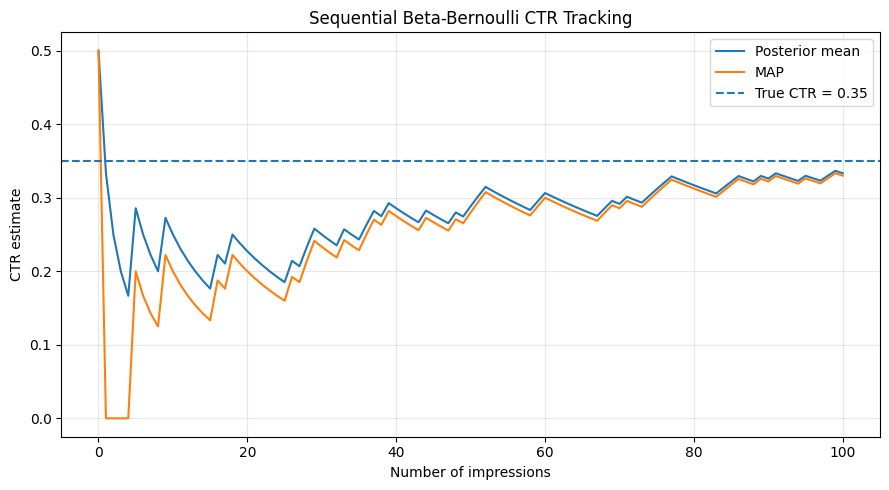

Observed clicks: 33 out of 100
Final posterior: Beta(34, 68)
Final posterior mean: 0.3333
Final MAP estimate: 0.3300
Absolute mean error at k = 10: 0.1000
Absolute mean error at k = 100: 0.0167


,step,click,alpha,beta,posterior_mean,MAP
0,1,0,1.0,2.0,0.333333,0.000000
1,2,0,1.0,3.0,0.250000,0.000000
2,3,0,1.0,4.0,0.200000,0.000000
3,4,0,1.0,5.0,0.166667,0.000000
4,5,1,2.0,5.0,0.285714,0.200000
...,...,...,...,...,...,...
95,96,0,32.0,66.0,0.326531,0.322917
96,97,0,32.0,67.0,0.323232,0.319588
97,98,1,33.0,67.0,0.330000,0.326531
98,99,1,34.0,67.0,0.336634,0.333333


In [9]:
rng = np.random.default_rng(42)

theta_true = 0.35
n_impressions = 100

# Uniform Beta(1, 1) prior.
alpha = 1.0
beta_parameter = 1.0

mean_history = [
    alpha / (alpha + beta_parameter)
]
map_history = [0.5]
ctr_records = []

for step in range(1, n_impressions + 1):
    click = int(rng.random() < theta_true)

    # Conjugate Beta-Bernoulli update.
    alpha = alpha + click
    beta_parameter = beta_parameter + (1 - click)

    posterior_mean = alpha / (
        alpha + beta_parameter
    )

    # MAP including boundary cases.
    if alpha > 1 and beta_parameter > 1:
        posterior_map = (
            (alpha - 1)
            / (alpha + beta_parameter - 2)
        )
    elif alpha <= 1 < beta_parameter:
        posterior_map = 0.0
    elif beta_parameter <= 1 < alpha:
        posterior_map = 1.0
    else:
        posterior_map = 0.5

    mean_history.append(posterior_mean)
    map_history.append(posterior_map)

    ctr_records.append(
        {
            "step": step,
            "click": click,
            "alpha": alpha,
            "beta": beta_parameter,
            "posterior_mean": posterior_mean,
            "MAP": posterior_map,
        }
    )

ctr_results = pd.DataFrame(ctr_records)
steps = np.arange(0, n_impressions + 1)

plt.figure(figsize=(9, 5))
plt.plot(
    steps,
    mean_history,
    label="Posterior mean",
)
plt.plot(
    steps,
    map_history,
    label="MAP",
)
plt.axhline(
    theta_true,
    linestyle="--",
    label="True CTR = 0.35",
)
plt.title("Sequential Beta-Bernoulli CTR Tracking")
plt.xlabel("Number of impressions")
plt.ylabel("CTR estimate")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(
    f"Observed clicks: "
    f"{ctr_results['click'].sum()} "
    f"out of {n_impressions}"
)
print(
    f"Final posterior: "
    f"Beta({alpha:.0f}, {beta_parameter:.0f})"
)
print(
    f"Final posterior mean: "
    f"{mean_history[-1]:.4f}"
)
print(
    f"Final MAP estimate: "
    f"{map_history[-1]:.4f}"
)
print(
    f"Absolute mean error at k = 10: "
    f"{abs(mean_history[10] - theta_true):.4f}"
)
print(
    f"Absolute mean error at k = 100: "
    f"{abs(mean_history[100] - theta_true):.4f}"
)

display(ctr_results)

### Convergence Analysis

The estimates fluctuate strongly during the first few impressions because each observation represents a large fraction of the available evidence. With the fixed seed, 33 clicks are observed in 100 impressions. The final posterior is $\operatorname{Beta}(34,68)$, with posterior mean $0.3333$ and MAP $0.3300$. The posterior mean error decreases from $0.10$ at step 10 to approximately $0.0167$ at step 100.

As $k$ grows, the data contribution becomes much larger than the initial $\operatorname{Beta}(1,1)$ prior. Thus, the prior strongly affects the earliest estimates but has progressively less influence as evidence accumulates.

# Q Bayesian Estimations for Structural Health Monitoring via Bounded Grid Updates

In aerospace and civil engineering, Structural Health Monitoring (SHM) is critical for detecting damage before a catastrophic failure occurs. Consider an aircraft wing or a bridge girder equipped with specialized vibration sensors. Over time, environmental fatigue or dynamic impacts can cause micro-fractures, resulting in a reduction of the component's mechanical stiffness.

Let $\Theta = \theta$ represent the structural **remaining stiffness efficiency factor**, where $\theta$ is physically bounded to the interval:

$$\theta \in (0, 1]$$

* $\theta = 1.0$ indicates a perfectly pristine, undamaged structural component.
* $\theta \to 0$ signifies critical degradation or severe structural cracking.

Let $K_{\text{nominal}}$ be the known, baseline stiffness of the structural component when it is entirely healthy. At each sequential inspection time step $k$ (where $k = 1, 2, \dots, n$), a sensor collects a noisy experimental stiffness measurement $y_k$.

Engineers model the degradation physics via a non-linear relationship with multiplicative log-normal measurement noise to prevent non-physical negative values:

$$y_k = \theta \cdot K_{\text{nominal}} \cdot e^{\epsilon_k}, \qquad \epsilon_k \sim \mathscr{N}(0, \sigma^2)$$

where $\sigma$ is the standard deviation of the sensor noise in log-space.

Let $\mathbf{y}^{(k)} = (y_1, y_2, \dots, y_k)$ represent the **running history vector of observed sensor readings** up to the current inspection milestone. Before deploying the sensors, engineers utilize an initial prior distribution $f_{\Theta}^{(0)}(\theta)$ over the domain $(0, 1]$ based on historical manufacturing specifications. As the sensor stream arrives, the posterior distribution calculated at step $k-1$ serves directly as the prior distribution for step $k$.

---

### **Tasks**

#### **1. Prior Belief Boundaries**

Before data collection begins, engineers assume the component is highly likely to be healthy, modeling this using a bounded Beta distribution as the initial prior: $\Theta \sim \text{Beta}(8, 1.5)$.

* Plot this initial prior density function using Plotly over the restricted physical domain $\theta \in [0.01, 1.0]$.
* Calculate the expected prior stiffness efficiency $\mathbb{E}[\Theta^{(0)}]$ analytically. Explain why this specific distribution serves as an appropriate initial prior for an engineering component assumed to be healthy.

#### **2. Structural Likelihood Formulation**

Using the change of variables or properties of the log-normal distribution, write down the mathematical likelihood contribution $L(y_k \mid \theta)$ of a *single* continuous sensor measurement $y_k$ at inspection step $k$, given the true stiffness factor $\theta$. Following this, write down the joint likelihood function for the running history vector $\mathbf{y}^{(k)}$.

#### **3. Mathematical Formulation of the Non-Conjugate Grid Update**

Explain why an exact closed-form analytical solution for the posterior density $f_{\Theta \mid \mathbf{Y}^{(k)}}(\theta \mid \mathbf{y}^{(k)})$ does not exist when combining a Beta prior with this log-normal structural likelihood. Write down the recursive relationship for the posterior density at step $k$ up to a proportionality constant.

#### **4. Running Point Estimates**

Because a closed-form formula is unavailable, we must define point estimators through numerical integration. Write down the definite integral equations over the bounded domain $(0, 1]$ required to compute:

* The **Running Posterior Mean** ($\widehat{\theta}_{\mathrm{Bayes}}^{(k)}$)
* The **Running Maximum A Posteriori** ($\widehat{\theta}_{\mathrm{MAP}}^{(k)}$)

#### **5. Algorithmic Grid Approximation and Normalization**

Describe the step-by-step numerical procedure to maintain this distribution on a discrete grid of $\theta$-values. Explicitly state how you would handle the boundary limits computationally and how you would perform the sequential normalization step using the trapezoidal rule after a new sensor reading $y_k$ is observed.

#### **6. Performance Tracking and Degradation Convergence Analysis**

Suppose an impact occurs, and the true, hidden remaining stiffness drops to $\theta_{\text{true}} = 0.68$. Write a Python script using Plotly to simulate an engineered monitoring timeline across $n = 15$ continuous sensor measurements ($K_{\text{nominal}} = 50.0 \text{ kN/mm}$, $\sigma = 0.15$):

* **Simulate Sensor Stream:** Programmatically generate noisy sensor readings $y_k$ by drawing random values from the underlying log-normal physics model centered at $\theta_{\text{true}}$.
* **Track Estimators:** Loop sequentially through each step. At each step, update the unnormalized grid, normalize it via `np.trapezoid`, and compute both $\widehat{\theta}_{\mathrm{Bayes}}^{(k)}$ and $\widehat{\theta}_{\mathrm{MAP}}^{(k)}$.
* **Visualize Curves & Timeline:** Generate two plots:
1. A plot showing the progression of the full posterior density curves at milestones $k \in \{0, 1, 2, 5, 10, 15\}$.
2. A line chart tracking the convergence of both $\widehat{\theta}_{\mathrm{Bayes}}^{(k)}$ and $\widehat{\theta}_{\mathrm{MAP}}^{(k)}$ from step $0$ to $15$ against a horizontal reference line at $\theta_{\text{true}} = 0.68$.


* **Analysis:** Evaluate the behavior of the distribution. How many sensor readings did it take for the system to overcome the initially optimistic "healthy" prior and confidently isolate the 68% damage state? What does the narrowing of the density curves imply about structural safety thresholds?

## Solution 3.1 — Initial Bounded Prior

The initial prior is

$$
\Theta\sim\operatorname{Beta}(8,1.5).
$$

Its expected value is

$$
E[\Theta]
=
\frac{8}{8+1.5}
=
0.8421.
$$

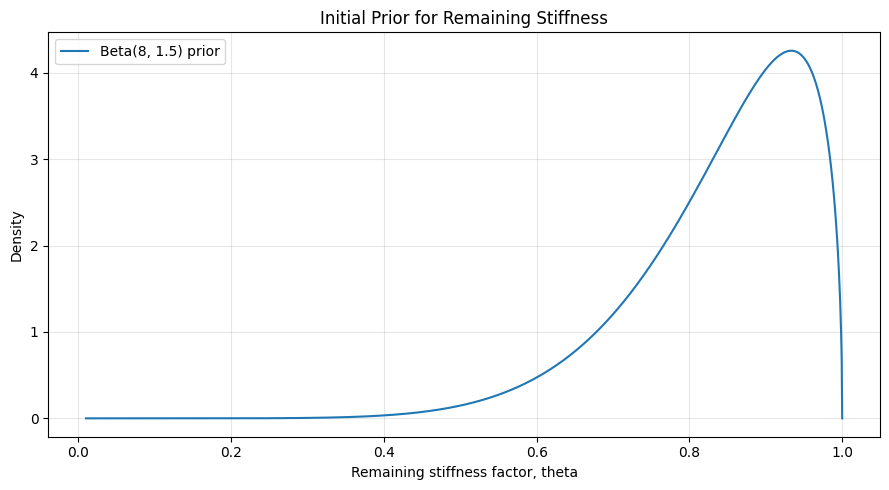

Analytical prior mean = 0.8421


In [10]:
theta_grid = np.linspace(0.01, 1.0, 1500)

prior_density = beta_dist.pdf(
    theta_grid,
    8,
    1.5,
)
prior_density = prior_density / np.trapezoid(
    prior_density,
    theta_grid,
)

plt.figure(figsize=(9, 5))
plt.plot(
    theta_grid,
    prior_density,
    label="Beta(8, 1.5) prior",
)
plt.title("Initial Prior for Remaining Stiffness")
plt.xlabel("Remaining stiffness factor, theta")
plt.ylabel("Density")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(
    f"Analytical prior mean = "
    f"{8 / (8 + 1.5):.4f}"
)

## Solution 3.2 — Log-Normal Structural Likelihood

The observation model is

$$
Y_k=\theta K_{\text{nominal}}e^{\epsilon_k},
\qquad
\epsilon_k\sim N(0,\sigma^2).
$$

Taking logarithms gives

$$
\log Y_k
=
\log(\theta K_{\text{nominal}})+\epsilon_k.
$$

Therefore,

$$
Y_k\mid\Theta=\theta
\sim
\operatorname{LogNormal}
\left(\log(\theta K_{\text{nominal}}),\sigma^2\right).
$$

For $y_k>0$,

$$
\boxed{
L(y_k\mid\theta)
=
\frac{1}{y_k\sigma\sqrt{2\pi}}
\exp\left[
-\frac{
\left(\log y_k-\log(\theta K_{\text{nominal}})\right)^2
}{2\sigma^2}
\right]
}.
$$

Assuming conditional independence,

$$
L(\mathbf y^{(k)}\mid\theta)
=
\prod_{i=1}^{k}
\frac{1}{y_i\sigma\sqrt{2\pi}}
\exp\left[
-\frac{
\left(\log y_i-\log(\theta K_{\text{nominal}})\right)^2
}{2\sigma^2}
\right].
$$

## Solution 3.3 — Non-Conjugate Recursive Update

A Beta prior has a kernel of the form

$$
\theta^{\alpha-1}(1-\theta)^{\beta-1}.
$$

The log-normal likelihood contains

$$
\exp\left[
-\frac{(\log y_k-\log(\theta K_{\text{nominal}}))^2}{2\sigma^2}
\right],
$$

which cannot be absorbed into the Beta kernel by updating $\alpha$ and $\beta$. Therefore, the model is non-conjugate.

The recursive posterior is

$$
\boxed{
f_k(\theta)
\propto
L(y_k\mid\theta)f_{k-1}(\theta),
\qquad 0<\theta\le1
}.
$$

The normalized posterior is

$$
f_k(\theta)
=
\frac{L(y_k\mid\theta)f_{k-1}(\theta)}
{\int_0^1 L(y_k\mid u)f_{k-1}(u)\,du}.
$$

## Solution 3.4 — Numerical Point Estimates

The running posterior mean is

$$
\boxed{
\widehat\theta_{\text{Bayes}}^{(k)}
=
\int_0^1 \theta f_k(\theta)\,d\theta
}.
$$

The running MAP is

$$
\boxed{
\widehat\theta_{\text{MAP}}^{(k)}
=
\operatorname*{arg\,max}_{0<\theta\le1}f_k(\theta)
}.
$$

On a numerical grid, the integral is approximated using the trapezoidal rule and the MAP is the grid value with the largest posterior density.

## Solution 3.5 — Grid Approximation Procedure

1. Use a grid such as $[0.01,1.0]$. The lower limit is kept above zero because $\log(0)$ is undefined.
2. Evaluate the $\operatorname{Beta}(8,1.5)$ prior at every grid point.
3. Normalize the prior:
   $$
   f_0(\theta_j)\leftarrow
   \frac{f_0(\theta_j)}
   {\operatorname{trapz}(f_0,\theta)}.
   $$
4. For each sensor measurement, calculate the log-normal likelihood at every grid point.
5. Multiply the previous posterior by this likelihood.
6. Normalize:
   $$
   Z_k\approx\operatorname{trapz}(\widetilde f_k,\theta),
   \qquad
   f_k=\widetilde f_k/Z_k.
   $$
7. Calculate the posterior mean and MAP.
8. A log-density implementation can be used if many observations cause numerical underflow.

## Solution 3.6 — Structural Monitoring Simulation

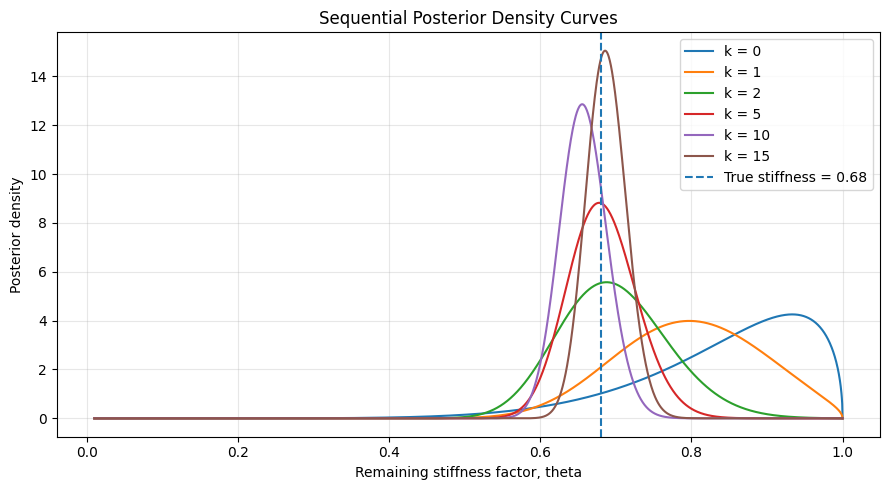

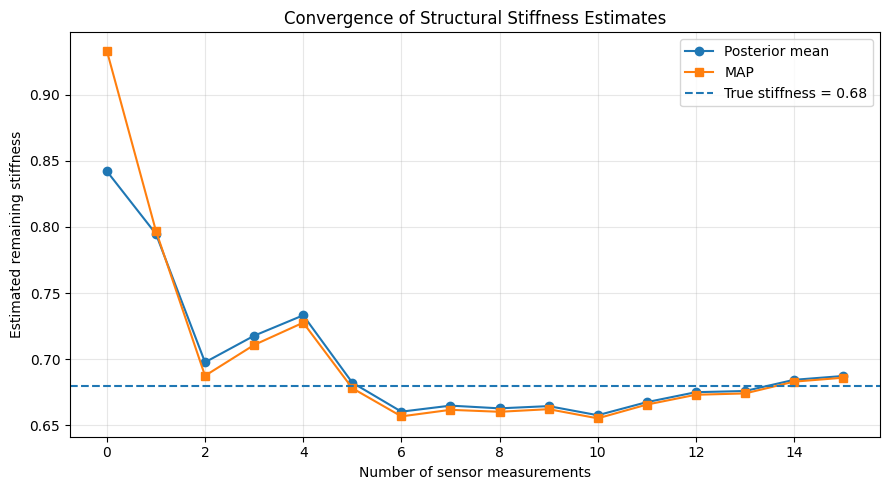

Initial posterior mean: 0.8421
Final posterior mean: 0.6873
Final MAP estimate: 0.6860
Posterior SD: 0.1125 at k = 0 -> 0.0266 at k = 15
First step meeting |mean - true| <= 0.03 and SD <= 0.05: 5


,step,sensor_reading,posterior_mean,MAP,posterior_sd
0,1,35.590121,0.794674,0.796948,0.092630
1,2,29.089082,0.697669,0.687499,0.071890
2,3,38.051032,0.717735,0.710775,0.060896
3,4,39.151754,0.733173,0.727614,0.054073
4,5,25.373498,0.682290,0.678089,0.045434
5,6,27.967234,0.660357,0.656793,0.040243
6,7,34.658277,0.664911,0.661746,0.037536
7,8,32.424819,0.662861,0.660260,0.035026
8,9,33.914422,0.664548,0.662241,0.033119
9,10,29.916314,0.657658,0.655308,0.031110


In [11]:
rng = np.random.default_rng(42)

theta_true = 0.68
K_nominal = 50.0
sigma = 0.15
n_measurements = 15

theta_grid = np.linspace(0.01, 1.0, 2000)

posterior = beta_dist.pdf(
    theta_grid,
    8,
    1.5,
)
posterior = posterior / np.trapezoid(
    posterior,
    theta_grid,
)

milestone_steps = {0, 1, 2, 5, 10, 15}
posterior_curves = {0: posterior.copy()}

mean_history = [
    np.trapezoid(
        theta_grid * posterior,
        theta_grid,
    )
]
map_history = [
    theta_grid[np.argmax(posterior)]
]
sd_history = [
    np.sqrt(
        np.trapezoid(
            (theta_grid - mean_history[0]) ** 2
            * posterior,
            theta_grid,
        )
    )
]

shm_records = []

for step in range(1, n_measurements + 1):
    random_error = rng.normal(0, sigma)

    sensor_reading = (
        theta_true
        * K_nominal
        * np.exp(random_error)
    )

    log_ratio = np.log(
        sensor_reading
        / (theta_grid * K_nominal)
    )

    likelihood = (
        1
        / (
            sensor_reading
            * sigma
            * np.sqrt(2 * np.pi)
        )
        * np.exp(
            -(log_ratio ** 2)
            / (2 * sigma ** 2)
        )
    )

    # Non-conjugate grid update.
    posterior = posterior * likelihood
    posterior = posterior / np.trapezoid(
        posterior,
        theta_grid,
    )

    posterior_mean = np.trapezoid(
        theta_grid * posterior,
        theta_grid,
    )
    posterior_map = theta_grid[
        np.argmax(posterior)
    ]
    posterior_sd = np.sqrt(
        np.trapezoid(
            (theta_grid - posterior_mean) ** 2
            * posterior,
            theta_grid,
        )
    )

    mean_history.append(posterior_mean)
    map_history.append(posterior_map)
    sd_history.append(posterior_sd)

    if step in milestone_steps:
        posterior_curves[step] = posterior.copy()

    shm_records.append(
        {
            "step": step,
            "sensor_reading": sensor_reading,
            "posterior_mean": posterior_mean,
            "MAP": posterior_map,
            "posterior_sd": posterior_sd,
        }
    )

shm_results = pd.DataFrame(shm_records)

# Posterior density curves at selected steps.
plt.figure(figsize=(9, 5))

for step in sorted(posterior_curves):
    plt.plot(
        theta_grid,
        posterior_curves[step],
        label=f"k = {step}",
    )

plt.axvline(
    theta_true,
    linestyle="--",
    label="True stiffness = 0.68",
)
plt.title("Sequential Posterior Density Curves")
plt.xlabel("Remaining stiffness factor, theta")
plt.ylabel("Posterior density")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Posterior mean and MAP convergence.
steps = np.arange(0, n_measurements + 1)

plt.figure(figsize=(9, 5))
plt.plot(
    steps,
    mean_history,
    marker="o",
    label="Posterior mean",
)
plt.plot(
    steps,
    map_history,
    marker="s",
    label="MAP",
)
plt.axhline(
    theta_true,
    linestyle="--",
    label="True stiffness = 0.68",
)
plt.title("Convergence of Structural Stiffness Estimates")
plt.xlabel("Number of sensor measurements")
plt.ylabel("Estimated remaining stiffness")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

criterion_steps = [
    row["step"]
    for row in shm_records
    if abs(
        row["posterior_mean"] - theta_true
    ) <= 0.03
    and row["posterior_sd"] <= 0.05
]

if criterion_steps:
    first_confident_step = criterion_steps[0]
else:
    first_confident_step = None

print(
    f"Initial posterior mean: "
    f"{mean_history[0]:.4f}"
)
print(
    f"Final posterior mean: "
    f"{mean_history[-1]:.4f}"
)
print(
    f"Final MAP estimate: "
    f"{map_history[-1]:.4f}"
)
print(
    f"Posterior SD: {sd_history[0]:.4f} "
    f"at k = 0 -> {sd_history[-1]:.4f} "
    f"at k = 15"
)
print(
    "First step meeting "
    "|mean - true| <= 0.03 and SD <= 0.05: "
    f"{first_confident_step}"
)

display(shm_results)

### Degradation and Safety Analysis

The prior begins with a mean of approximately $0.842$, reflecting an optimistic healthy-state belief. The first two sensor readings move the estimate sharply toward the true value. Using the explicit confidence criterion

$$
|\widehat\theta_{\text{Bayes}}^{(k)}-0.68|\le0.03
\quad\text{and}\quad
\operatorname{SD}(\Theta\mid\mathbf y^{(k)})\le0.05,
$$

the simulation first satisfies the criterion after approximately five readings. At step 15, the posterior mean is about $0.687$, the MAP is about $0.686$, and the posterior standard deviation is about $0.027$.

The narrowing curves indicate reduced uncertainty. In a safety system, this supports increasingly decisive comparisons with inspection, repair, or shutdown thresholds. However, a real engineering decision should also incorporate model error, calibration uncertainty, and conservative safety margins.

# Q. Gaussian Mixture Clustering as Conditional Updating

Consider a dataset
$$
x_1,x_2,\dots,x_n\in\mathbb R^d.
$$
We wish to cluster these observations into $K$ groups. Instead of assigning each point deterministically to a cluster at the beginning, we introduce a latent random variable
$$
C_i\in{1,\dots,K},
$$
where $C_i=k$ means that the observation $x_i$ belongs to cluster $k$.
Let the prior probability of cluster membership be
$$
P(C_i=k)=\phi_k,
$$
where
$$
\phi_k\ge 0,
\qquad
\sum_{k=1}^K \phi_k=1.
$$

Conditional on $C_i=k$, assume that the observation $X_i$ is generated from a multivariate Gaussian distribution:
$$
X_i\mid C_i=k
\sim
\mathscr N(\mu_k,\Sigma_k),
$$
where
$$
\mu_k\in\mathbb R^d,
\qquad
\Sigma_k\in\mathbb R^{d\times d}
$$
are the mean vector and covariance matrix of cluster $k$.

The model parameters
$$
\phi_k,\mu_k,\Sigma_k,
\qquad k=1,\dots,K,
$$
are assumed to be fixed but unknown.

---

1. Deriving the Marginal Density:
Using the law of total probability, show that the marginal density of $X_i$ is
$$
p(x_i)=\sum_{k=1}^K
\phi_k
\mathscr N(x_i\mid \mu_k,\Sigma_k).
$$
Explain why this density is called a Gaussian mixture density.

---

2. Deriving the Posterior Cluster Probability:
For a fixed observation $x_i$, use Bayes' rule to derive
$$
P(C_i=k\mid X_i=x_i)=\frac{
P(X_i=x_i\mid C_i=k)P(C_i=k)
}{
\sum_{j=1}^K P(X_i=x_i\mid C_i=j)P(C_i=j)
}.
$$
Then substitute the Gaussian model and the cluster prior to obtain
$$
P(C_i=k\mid X_i=x_i)=\frac{
\phi_k\mathscr N(x_i\mid \mu_k,\Sigma_k)
}{
\sum_{j=1}^K
\phi_j\mathscr N(x_i\mid \mu_j,\Sigma_j)
}.
$$
This quantity is called the responsibility of cluster $k$ for data point $x_i$, and is denoted by
$$
\gamma_{ik}=P(C_i=k\mid X_i=x_i).
$$
Explain why $\gamma_{ik}$ may be interpreted as a posterior probability of cluster membership.

---

3. One-Hot Encoding of the Latent Cluster Variable:
Now define a one-hot encoded latent random vector
$$
Z_i=
\begin{bmatrix}
Z_{i1}\\
Z_{i2}\\
\vdots\\
Z_{iK}
\end{bmatrix},
$$
where
$$
Z_{ik}=\begin{cases}
1, & \text{if } C_i=k,\\
0, & \text{otherwise}.
\end{cases}
$$
Show that
$$
\mathbb E[Z_{ik}\mid X_i=x_i]=P(C_i=k\mid X_i=x_i).
$$
Hence show that
$$
\mathbb E[Z_i\mid X_i=x_i]=\begin{bmatrix}
\gamma_{i1}\\
\gamma_{i2}\\
\vdots\\
\gamma_{iK}
\end{bmatrix}.
$$
Conclude that the soft cluster assignment in a Gaussian mixture model is precisely the conditional expectation
$$
\mathbb E[Z_i\mid X_i=x_i].
$$

---

4. From Soft Assignment to Hard Clustering:
The vector
$$
\mathbb E[Z_i\mid X_i=x_i]
$$
gives a soft assignment of $x_i$ to all clusters. A hard cluster assignment can be obtained by choosing the cluster with the largest posterior probability:
$$
\widehat C_i=\operatorname{arg\,max}_{1\le k\le K}
\gamma_{ik}.
$$
Explain the difference between soft clustering and hard clustering in this context.

---

5. Conditional Expectation of the Observation Given the Cluster:
Show that
$$
\mathbb E[X_i\mid C_i=k]=\mu_k.
$$
Explain why $\mu_k$ can be interpreted as the center of cluster $k$.
Then compare the two conditional expectations
$$
\mathbb E[Z_i\mid X_i=x_i]
$$
and
$$
\mathbb E[X_i\mid C_i=k].
$$
Explain why the first gives the soft cluster membership of an observed point, while the second gives the mean location of a cluster.

---

6. The Complete-Data Likelihood
If the latent labels $z_i$ were known, the complete-data likelihood would be
$$
p(x_1,\dots,x_n,z_1,\dots,z_n)=\prod_{i=1}^n
\prod_{k=1}^K
\left[
\phi_k
\mathscr N(x_i\mid \mu_k,\Sigma_k)
\right]^{z_{ik}}.
$$
Take the logarithm and show that the complete-data log-likelihood is
$$
\ell_c=\sum_{i=1}^n
\sum_{k=1}^K
z_{ik}
\left[
\log \phi_k
+
\log \mathscr N(x_i\mid \mu_k,\Sigma_k)
\right].
$$
Explain why this expression would be easy to maximize if the values of $z_{ik}$ were known.

---

7. The EM Interpretation:
In practice, the latent variables $Z_i$ are not observed. The EM algorithm replaces the unknown indicators $z_{ik}$ by their conditional expectations given the observed data and current parameter estimates:
$$
z_{ik}
\quad\leadsto\quad
\mathbb E[Z_{ik}\mid X_i=x_i].
$$
That is,
$$
z_{ik}
\quad\leadsto\quad
\gamma_{ik}.
$$
This is the E-step of the EM algorithm.
Using this idea, write the expected complete-data log-likelihood:
$$
Q=\sum_{i=1}^n
\sum_{k=1}^K
\gamma_{ik}
\left[
\log \phi_k
+
\log \mathscr N(x_i\mid \mu_k,\Sigma_k)
\right].
$$
Explain why the E-step can be interpreted as a conditional update of cluster membership probabilities.

---

8. Parameter Updates:
By maximizing $Q$ with respect to the model parameters, derive the standard GMM updates:
$$
N_k=\sum_{i=1}^n \gamma_{ik},
$$
$$
\phi_k^{\text{new}}=\frac{N_k}{n},
$$
$$
\mu_k^{\text{new}}=\frac{1}{N_k}
\sum_{i=1}^n
\gamma_{ik}x_i,
$$
and
$$
\Sigma_k^{\text{new}}=\frac{1}{N_k}
\sum_{i=1}^n
\gamma_{ik}
(x_i-\mu_k^{\text{new}})
(x_i-\mu_k^{\text{new}})^T.
$$
Explain how the responsibility $\gamma_{ik}$ acts as a fractional membership weight of observation $x_i$ in cluster $k$.

---

9. Interpretation:
Write a short paragraph explaining why GMM clustering can be viewed as a repeated process of conditional updating.
Your answer should mention the following points:

* The mixture weight $\phi_k$ is the prior probability of cluster $k$.
* The Gaussian density $\mathscr N(x_i\mid \mu_k,\Sigma_k)$ measures how compatible $x_i$ is with cluster $k$.
* The responsibility $\gamma_{ik}$ is the posterior probability of cluster $k$ after observing $x_i$.
* The soft assignment vector is
$$
\mathbb E[Z_i\mid X_i=x_i].
$$

* The M-step updates the cluster parameters using these posterior membership probabilities as weights.
Conclude that Gaussian mixture clustering is probabilistic clustering based on conditional expectations of latent cluster membership variables.

---

Here is a perfectly tailored question that you can add as the final part (**Part 10**) of your assignment notebook to bridge your theoretical derivations with your code implementation:

---

10. Computational Simulation and Out-of-Sample Validation

Using the theoretical framework established in the previous parts, write a Python class named `GMMFinancialSegmenter` that implements a two-dimensional Gaussian Mixture Model (GMM) using `scikit-learn` and visualizes the results interactively using `Plotly`. Your implementation should fulfill the following criteria:

* **Data Splitting and Scaling:** Accept a dataset containing two continuous features (e.g., mimicking financial behaviors like `PURCHASES` and `CREDIT_LIMIT`), standardize the features to handle variance scaling, and split the data into an 80% training set and a 20% validation/test set.
* **EM Execution:** Fit a GMM with $K=3$ components on the training data using the Expectation-Maximization (EM) algorithm, printing whether the model successfully converged and the number of iterations required.
* **Out-of-Sample Performance:** Compute and output the average log-likelihood score over the unseen test set to validate how well the learned density functions generalize to new data.
* **Interactive Visualizations:** Implement methods to generate three distinct Plotly figures:
1. An empirical **2D Density Heatmap** of the raw training data with marginal distributions to inspect its underlying multimodal structure.
2. A **Training Assignment Plot** that overlays the training data points on top of a continuous contour map showing the maximum posterior responsibilities ($\gamma_{ik}$) computed across a fine coordinate grid.
3. A **Test Assignment Plot** that replicates the contour boundary visualization but overlays out-of-sample test data points to expose the physical regions of cluster ambiguity.



Briefly evaluate the resulting plots. Explain how the continuous background contour map visually demonstrates the soft assignment expectation vector $\mathbb{E}[Z_i \mid X_i = x_{\text{grid}}]$ that you proved analytically in Part 3.

Use the dataset

https://www.kaggle.com/datasets/arjunbhasin2013/ccdata

## Solution 4.1 — Marginal Gaussian Mixture Density

By the law of total probability,

$$
p(x_i)
=
\sum_{k=1}^{K}
p(x_i,C_i=k)
=
\sum_{k=1}^{K}
p(x_i\mid C_i=k)P(C_i=k).
$$

Substituting the model assumptions gives

$$
\boxed{
p(x_i)
=
\sum_{k=1}^{K}
\phi_k\mathcal N(x_i\mid\mu_k,\Sigma_k)
}.
$$

It is called a Gaussian mixture because the overall density is a weighted sum of several Gaussian component densities.

## Solution 4.2 — Posterior Cluster Probability

Using Bayes' rule,

$$
P(C_i=k\mid X_i=x_i)
=
\frac{
P(X_i=x_i\mid C_i=k)P(C_i=k)
}{
\sum_{j=1}^{K}
P(X_i=x_i\mid C_i=j)P(C_i=j)
}.
$$

Therefore,

$$
\boxed{
\gamma_{ik}
=
P(C_i=k\mid X_i=x_i)
=
\frac{
\phi_k\mathcal N(x_i\mid\mu_k,\Sigma_k)
}{
\sum_{j=1}^{K}
\phi_j\mathcal N(x_i\mid\mu_j,\Sigma_j)
}
}.
$$

It is a posterior probability because it updates the prior cluster probability $\phi_k$ after observing $x_i$.

## Solution 4.3 — Conditional Expectation of the One-Hot Variable

Because $Z_{ik}$ is an indicator,

$$
E[Z_{ik}\mid X_i=x_i]
=
1\cdot P(Z_{ik}=1\mid X_i=x_i)
+
0\cdot P(Z_{ik}=0\mid X_i=x_i).
$$

Thus,

$$
\boxed{
E[Z_{ik}\mid X_i=x_i]
=
P(C_i=k\mid X_i=x_i)
=
\gamma_{ik}
}.
$$

Hence,

$$
\boxed{
E[Z_i\mid X_i=x_i]
=
\begin{bmatrix}
\gamma_{i1}\\
\vdots\\
\gamma_{iK}
\end{bmatrix}
}.
$$

The vector is the soft cluster assignment because its entries are nonnegative and sum to one.

## Solution 4.4 — Soft and Hard Clustering

Soft clustering retains all posterior membership probabilities. For example, $(0.10,0.65,0.25)$ expresses uncertainty across three clusters. Hard clustering keeps only the most likely label:

$$
\widehat C_i
=
\operatorname*{arg\,max}_{k}\gamma_{ik}.
$$

Hard assignments are easier to report, but they discard information about ambiguity near cluster boundaries.

## Solution 4.5 — Conditional Mean of an Observation

Since

$$
X_i\mid C_i=k\sim N(\mu_k,\Sigma_k),
$$

the conditional mean is

$$
\boxed{E[X_i\mid C_i=k]=\mu_k}.
$$

Thus, $\mu_k$ is the center of cluster $k$. The expectation $E[Z_i\mid X_i=x_i]$ describes the membership of a given observed point, whereas $E[X_i\mid C_i=k]$ describes the expected location of data generated by cluster $k$.

## Solution 4.6 — Complete-Data Log-Likelihood

If the latent indicators were known,

$$
p(X,Z)
=
\prod_{i=1}^{n}
\prod_{k=1}^{K}
\left[
\phi_k\mathcal N(x_i\mid\mu_k,\Sigma_k)
\right]^{z_{ik}}.
$$

Taking logarithms,

$$
\boxed{
\ell_c
=
\sum_{i=1}^{n}
\sum_{k=1}^{K}
z_{ik}
\left[
\log\phi_k
+
\log\mathcal N(x_i\mid\mu_k,\Sigma_k)
\right]
}.
$$

If $z_{ik}$ were known, each observation would already be assigned to a component. Estimating the weights, means, and covariances would then reduce to ordinary cluster-wise maximum-likelihood estimation.

## Solution 4.7 — EM Interpretation

The E-step calculates

$$
\gamma_{ik}
=
E[Z_{ik}\mid X_i=x_i,\text{current parameters}].
$$

Replacing the unknown indicators by these conditional expectations gives

$$
\boxed{
Q
=
\sum_{i=1}^{n}
\sum_{k=1}^{K}
\gamma_{ik}
\left[
\log\phi_k
+
\log\mathcal N(x_i\mid\mu_k,\Sigma_k)
\right]
}.
$$

The E-step is a conditional update because it converts prior component weights and component likelihoods into posterior membership probabilities after each observation is considered.

## Solution 4.8 — Parameter Updates

Define the effective membership count

$$
N_k=\sum_{i=1}^{n}\gamma_{ik}.
$$

Maximizing $Q$ with the constraint $\sum_k\phi_k=1$ gives

$$
\boxed{\phi_k^{\text{new}}=\frac{N_k}{n}}.
$$

The weighted Gaussian maximum-likelihood estimates are

$$
\boxed{
\mu_k^{\text{new}}
=
\frac{1}{N_k}\sum_{i=1}^{n}\gamma_{ik}x_i
}
$$

and

$$
\boxed{
\Sigma_k^{\text{new}}
=
\frac{1}{N_k}
\sum_{i=1}^{n}
\gamma_{ik}
(x_i-\mu_k^{\text{new}})
(x_i-\mu_k^{\text{new}})^T
}.
$$

Each $\gamma_{ik}$ acts as a fractional count. A point with responsibility $0.8$ contributes more strongly to component $k$ than a point with responsibility $0.1$.

## Solution 4.9 — Conditional-Updating Interpretation

A Gaussian mixture model repeatedly alternates between belief updating and parameter re-estimation. The mixture weight $\phi_k$ is the prior probability of component $k$. The Gaussian density measures the compatibility of $x_i$ with that component. Bayes' rule combines these quantities to produce the responsibility $\gamma_{ik}$, the posterior cluster probability. The soft assignment is $E[Z_i\mid X_i=x_i]$. The M-step then uses these posterior probabilities as weights to update the cluster parameters. Therefore, GMM clustering is probabilistic clustering based on repeated conditional expectations of latent membership variables.

## Solution 4.10 — Computational Simulation and Validation

The following implementation uses `PURCHASES` and `CREDIT_LIMIT` from the supplied credit-card dataset.

In [18]:
from pathlib import Path
import pandas as pd
import zipfile
import shutil


def ask_for_dataset():
    """
    Ask the user to upload or select CC GENERAL.csv or archive.zip.
    """

    uploaded_path = None

    # Google Colab: open an upload window.
    try:
        from google.colab import files

        print("Please upload CC GENERAL.csv or archive.zip")

        uploaded_files = files.upload()

        if not uploaded_files:
            raise FileNotFoundError("No file was uploaded.")

        uploaded_filename = next(iter(uploaded_files))
        uploaded_path = Path(uploaded_filename)

    # Normal Jupyter Notebook: ask for the file path.
    except ImportError:
        print("Please provide CC GENERAL.csv or archive.zip")

        file_path = input(
            "Enter the complete file path: "
        ).strip().strip('"').strip("'")

        uploaded_path = Path(file_path)

    if not uploaded_path.exists():
        raise FileNotFoundError(
            f"The selected file was not found: {uploaded_path}"
        )

    # If the uploaded file is a CSV, use it directly.
    if uploaded_path.suffix.lower() == ".csv":
        return uploaded_path

    # If the uploaded file is a ZIP, extract the CSV.
    if uploaded_path.suffix.lower() == ".zip":

        with zipfile.ZipFile(uploaded_path, "r") as zip_file:

            csv_files = [
                filename
                for filename in zip_file.namelist()
                if filename.lower().endswith(".csv")
            ]

            if not csv_files:
                raise FileNotFoundError(
                    "No CSV file was found inside the ZIP file."
                )

            # Prefer CC GENERAL.csv when it exists.
            selected_csv = next(
                (
                    filename
                    for filename in csv_files
                    if Path(filename).name.lower()
                    == "cc general.csv"
                ),
                csv_files[0],
            )

            output_path = (
                Path.cwd() / Path(selected_csv).name
            )

            with zip_file.open(selected_csv) as source_file:
                with open(output_path, "wb") as output_file:
                    shutil.copyfileobj(
                        source_file,
                        output_file,
                    )

        print(f"Dataset extracted to: {output_path}")

        return output_path

    raise ValueError(
        "Please upload a CSV file or ZIP file."
    )


# Ask the user for the dataset.
dataset_path = ask_for_dataset()

# Load the dataset.
credit_data = pd.read_csv(dataset_path)

print(f"Dataset loaded from: {dataset_path}")
print(f"Dataset shape: {credit_data.shape}")

display(credit_data.head())

Please upload CC GENERAL.csv or archive.zip


Saving CC GENERAL.csv to CC GENERAL.csv
Dataset loaded from: CC GENERAL.csv
Dataset shape: (8950, 18)


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


### Computational Evaluation

The model converges successfully in approximately 20 EM iterations. The average log-likelihood on the unseen test set is approximately $-1.689$ per observation in standardized feature space. Because this value is computed on held-out data, it measures how well the fitted mixture density generalizes beyond the training sample.

The fitted component centers indicate three broad financial-behavior groups:

1. low purchases with relatively low credit limits;
2. moderate purchases with medium-to-high credit limits;
3. high purchases with high credit limits.

The empirical density heatmap shows that the data are strongly concentrated in the lower-purchase region with additional higher-value subgroups. In the assignment plots, the background value at each grid location is

$$
\max_k P(C=k\mid X=x_{\text{grid}}).
$$

Values close to one indicate confident membership, while lower values indicate overlap and ambiguity. The full soft assignment at each location is the vector

$$
E[Z\mid X=x_{\text{grid}}]
=
(\gamma_1,\gamma_2,\gamma_3)^T.
$$

The contour plot displays the largest entry of this vector, while the point colors display the corresponding hard assignment. The test plot shows that the learned regions also provide meaningful assignments for unseen observations.